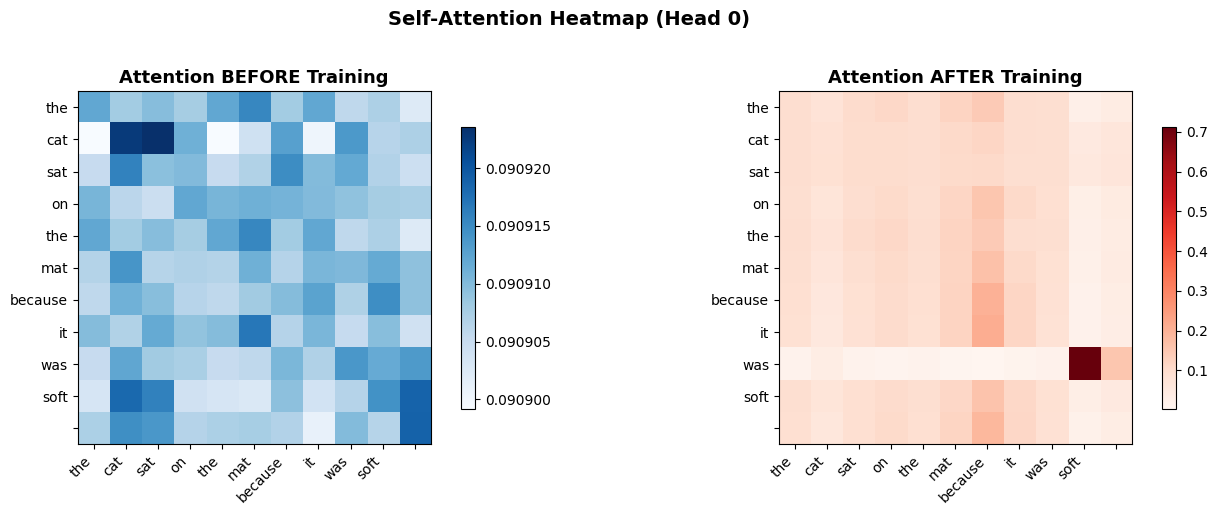

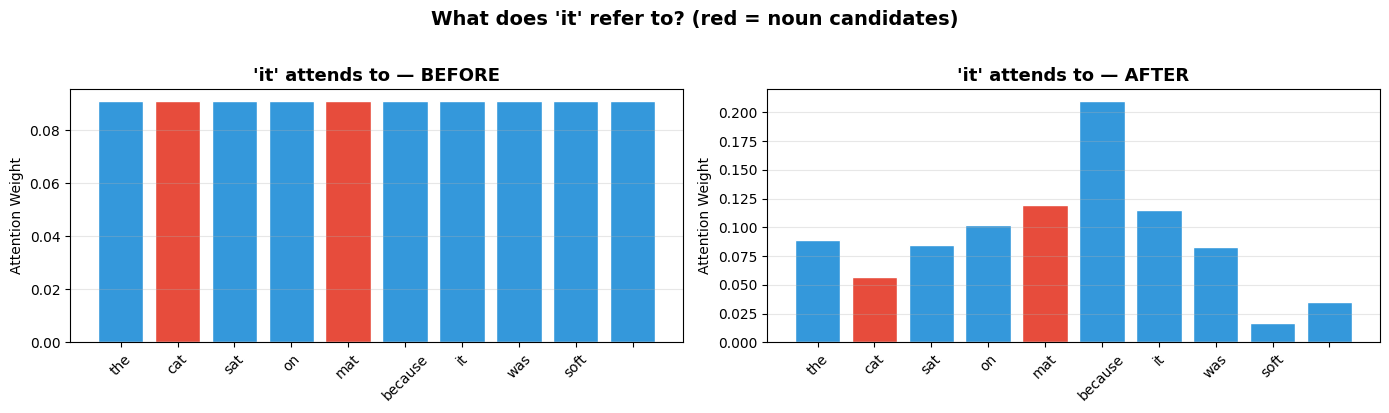


'it' attention BEFORE: {'the': 0.091, 'cat': 0.091, 'sat': 0.091, 'on': 0.091, 'mat': 0.091, 'because': 0.091, 'it': 0.091, 'was': 0.091, 'soft': 0.091, '': 0.091}
'it' attention AFTER:  {'the': 0.089, 'cat': 0.057, 'sat': 0.085, 'on': 0.102, 'mat': 0.12, 'because': 0.21, 'it': 0.115, 'was': 0.083, 'soft': 0.017, '': 0.035}


In [1]:
# ========================================================
# Week 13 : Self Attention without Positional Encoding
# ========================================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

# =========================================
# 1. Toy Data — "it" coreference
# =========================================
sentences = [
    "the cat sat on the mat because it was soft",
    "the cat sat on the mat because it was tired",
    "the dog ran to the park because it was excited",
    "the dog ran to the park because it was open",
    "the bird flew to the tree because it was tall",
    "the bird flew to the tree because it was hungry",
] * 300

SEQ_LEN = 12

vectorizer = tf.keras.layers.TextVectorization(
    output_mode="int",
    output_sequence_length=SEQ_LEN
)
vectorizer.adapt(sentences)
vocab = vectorizer.get_vocabulary()
vocab_size = len(vocab)

dataset = tf.data.Dataset.from_tensor_slices(sentences)
def make_lm_pair(text):
    tokens = vectorizer(text)
    return tokens[:-1], tokens[1:]
dataset = dataset.map(make_lm_pair).batch(64)

# =========================================
# 2. Model
# =========================================
d_model = 32
num_heads = 2

class SimpleTransformer(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(vocab_size, d_model)
        self.mha = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model)
        self.norm = tf.keras.layers.LayerNormalization()
        self.dense = tf.keras.layers.Dense(vocab_size)

    def call(self, x, return_attention=False):
        x = self.embedding(x)
        attn_output, attn_scores = self.mha(
            x, x, x, return_attention_scores=True)
        x = self.norm(x + attn_output)
        logits = self.dense(x)
        if return_attention:
            return logits, attn_scores
        return logits

model = SimpleTransformer()
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer="adam"
)

# =========================================
# 3. Before Training — Attention
# =========================================
sample_tokens = vectorizer([sentences[0]])[:, :-1]
words = [vocab[i] for i in sample_tokens.numpy()[0]]
_, attn_before = model(sample_tokens, return_attention=True)

# =========================================
# 4. Train
# =========================================
model.fit(dataset, epochs=50, verbose=0)

# =========================================
# 5. After Training — Attention
# =========================================
_, attn_after = model(sample_tokens, return_attention=True)

# =========================================
# 6. Attention Heatmap (Before vs After)
# =========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im1 = ax1.imshow(attn_before[0, 0].numpy(), cmap='Blues')
ax1.set_xticks(range(len(words))); ax1.set_xticklabels(words, rotation=45, ha='right')
ax1.set_yticks(range(len(words))); ax1.set_yticklabels(words)
ax1.set_title('Attention BEFORE Training', fontsize=13, fontweight='bold')
fig.colorbar(im1, ax=ax1, shrink=0.8)

im2 = ax2.imshow(attn_after[0, 0].numpy(), cmap='Reds')
ax2.set_xticks(range(len(words))); ax2.set_xticklabels(words, rotation=45, ha='right')
ax2.set_yticks(range(len(words))); ax2.set_yticklabels(words)
ax2.set_title('Attention AFTER Training', fontsize=13, fontweight='bold')
fig.colorbar(im2, ax=ax2, shrink=0.8)

fig.suptitle('Self-Attention Heatmap (Head 0)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# =========================================
# 7. "it" Attention Row (Before vs After)
# =========================================
it_idx = words.index("it")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

scores_before = attn_before[0, 0, it_idx].numpy()
colors_b = ['#e74c3c' if w in ['cat','dog','bird','mat','park','tree'] else '#3498db' for w in words]
ax1.bar(words, scores_before, color=colors_b, edgecolor='white')
ax1.set_title("'it' attends to — BEFORE", fontsize=13, fontweight='bold')
ax1.set_ylabel('Attention Weight'); ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

scores_after = attn_after[0, 0, it_idx].numpy()
colors_a = ['#e74c3c' if w in ['cat','dog','bird','mat','park','tree'] else '#3498db' for w in words]
ax2.bar(words, scores_after, color=colors_a, edgecolor='white')
ax2.set_title("'it' attends to — AFTER", fontsize=13, fontweight='bold')
ax2.set_ylabel('Attention Weight'); ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle("What does 'it' refer to? (red = noun candidates)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print(f"\n'it' attention BEFORE: {dict(zip(words, np.round(scores_before, 3)))}")
print(f"'it' attention AFTER:  {dict(zip(words, np.round(scores_after, 3)))}")